# GAT — Graph Attention Network on deep features

- **Node features:** multilevel deep embeddings (L2/L3-aware backbone).
- **Edge weights:** dynamic Gaussian kernel from raw RGB (skeleton + computed weights). The pre-baked `per_sample_adj/` files are **not** used here — edge weights are recomputed on GPU per batch, identical to SGCN.
- Tail-merge is auto-enabled for L2/L3; flat CE is the default training objective.

In [2]:
from pathlib import Path
import gc
import importlib
import warnings; warnings.filterwarnings('ignore')
import torch

import fgvd_utils
fgvd_utils = importlib.reload(fgvd_utils)
ExperimentConfig = fgvd_utils.ExperimentConfig
run_experiment = fgvd_utils.run_experiment

CKPT_ROOT = Path('checkpoints')
PLOT_ROOT = Path('plots')

def clear_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

## L1 — vehicle type


=== GAT | L1 | deep | hierarchical=False | tail_min=None ===
Samples: train=15702 val=3850 test=4890 | classes=7
Epoch 001 | train_acc=0.8045 val_acc=0.8205 | train_loss=1.0343 val_loss=0.9032
Epoch 005 | train_acc=0.8508 val_acc=0.8281 | train_loss=0.8251 val_loss=0.8622
Epoch 010 | train_acc=0.8517 val_acc=0.8491 | train_loss=0.8173 val_loss=0.8561
Epoch 015 | train_acc=0.8575 val_acc=0.8444 | train_loss=0.8082 val_loss=0.8549
Epoch 020 | train_acc=0.8566 val_acc=0.8527 | train_loss=0.8013 val_loss=0.8458
Epoch 025 | train_acc=0.8564 val_acc=0.8566 | train_loss=0.7981 val_loss=0.8332
Epoch 030 | train_acc=0.8601 val_acc=0.8452 | train_loss=0.7949 val_loss=0.8464
Epoch 035 | train_acc=0.8626 val_acc=0.8530 | train_loss=0.7898 val_loss=0.8375
Epoch 040 | train_acc=0.8640 val_acc=0.8540 | train_loss=0.7888 val_loss=0.8345

Test acc=0.8479 | top3=0.9751 | top5=0.9957 | macro_f1=0.7677
              precision    recall  f1-score   support

autorickshaw     0.9225    0.8687    0.8948     

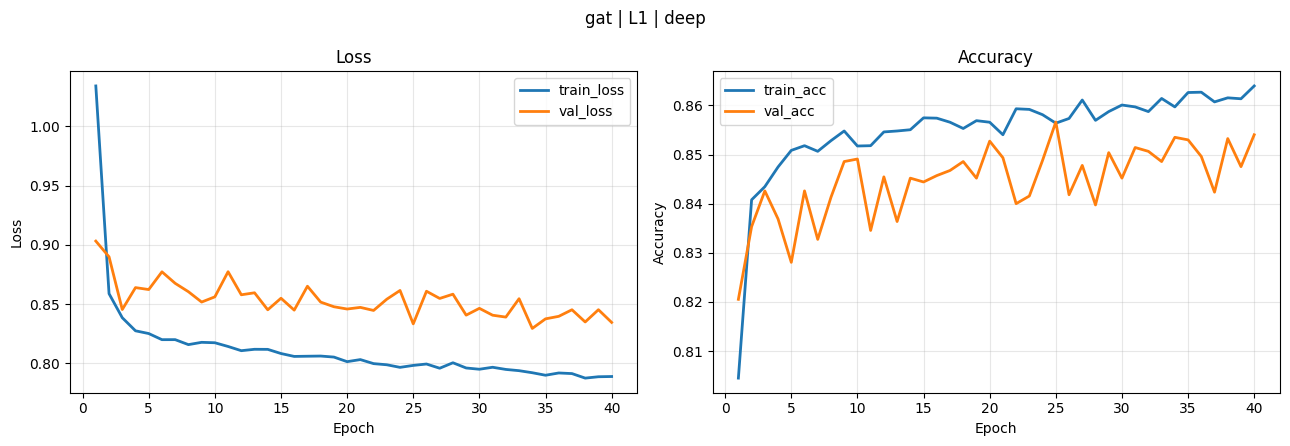

{'loss': 0.49401635246042824,
 'acc': 0.8478527607361963,
 'macro_f1': 0.7676861205929392,
 'weighted_f1': 0.8472252455904135,
 'top1_acc': 0.8478527607361963,
 'top3_acc': 0.9750511247443763,
 'top5_acc': 0.9957055214723927,
 'val_acc_best': 0.8566233766233766}

In [2]:
cfg_l1 = ExperimentConfig(
    method='gat', level='L1', feature_source='deep',
    epochs=40, batch_size=16, lr=5e-4, weight_decay=1e-3,
    hidden_dim=64, heads=8, dropout=0.4,
    use_logit_adjustment=False,
)
out_l1 = run_experiment(cfg_l1, ckpt_root=CKPT_ROOT, plot_root=PLOT_ROOT)
out_l1['metrics']

## L2 — manufacturer


=== GAT | L2 | deep | hierarchical=False | tail_min=20 ===
Samples: train=15702 val=3850 test=4890 | classes=46
Tail-merge: kept 41/59 classes | coverage train=0.991 val=0.990 test=0.992
Gradient accumulation: micro_batch=8 effective_batch=16
AMP mixed precision: enabled
Epoch 001 | train_acc=0.3870 val_acc=0.4356 | train_loss=3.6421 val_loss=3.4058
Epoch 005 | train_acc=0.4440 val_acc=0.4418 | train_loss=3.2171 val_loss=3.3759
Epoch 010 | train_acc=0.4573 val_acc=0.4483 | train_loss=3.1420 val_loss=3.3214
Epoch 015 | train_acc=0.4611 val_acc=0.4444 | train_loss=3.1018 val_loss=3.3422
Epoch 020 | train_acc=0.4658 val_acc=0.4249 | train_loss=3.0759 val_loss=3.3392
Epoch 025 | train_acc=0.4701 val_acc=0.4397 | train_loss=3.0515 val_loss=3.3628
Epoch 030 | train_acc=0.4776 val_acc=0.4543 | train_loss=3.0349 val_loss=3.3456
Epoch 035 | train_acc=0.4761 val_acc=0.4538 | train_loss=3.0162 val_loss=3.3743
Epoch 040 | train_acc=0.4823 val_acc=0.4584 | train_loss=2.9969 val_loss=3.3377
Epoch 0

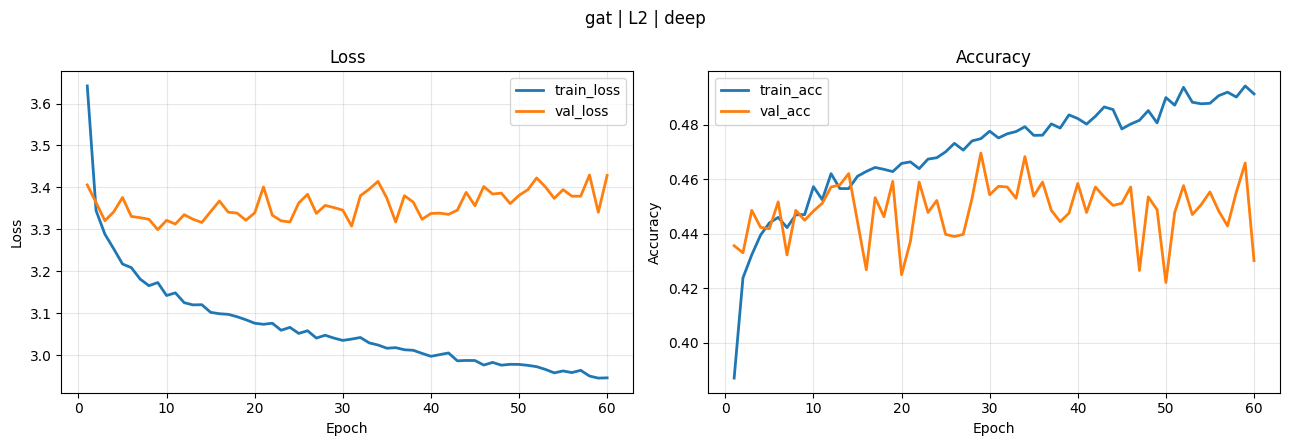

{'loss': 1.9929249441696821,
 'acc': 0.4603271983640082,
 'macro_f1': 0.2990813948000183,
 'weighted_f1': 0.4349416462074347,
 'top1_acc': 0.4607361963190184,
 'top3_acc': 0.6979550102249489,
 'top5_acc': 0.7930470347648262,
 'val_acc_best': 0.4696103896103896}

In [11]:
clear_cuda()
cfg_l2_flat = ExperimentConfig(
    method='gat', level='L2', feature_source='deep',
    epochs=60, batch_size=8, grad_accum_steps=2,
    lr=1e-3, weight_decay=1e-4,
    hidden_dim=128, heads=4, dropout=0.5,
    hierarchical=False,
    use_logit_adjustment=False,
    resume=False,
)
out_l2_flat = run_experiment(cfg_l2_flat, ckpt_root=CKPT_ROOT, plot_root=PLOT_ROOT)
out_l2_flat['metrics']

## L3 — model


=== GAT | L3 | deep | hierarchical=False | tail_min=20 ===
Samples: train=15702 val=3850 test=4890 | classes=135
Tail-merge: kept 93/209 classes | coverage train=0.955 val=0.951 test=0.953
Gradient accumulation: micro_batch=8 effective_batch=16
AMP mixed precision: enabled
Resumed from checkpoints/gat/deep/L3_all/last.pt (epoch 1).
Epoch 002 | train_acc=0.2250 val_acc=0.2961 | train_loss=6.2390 val_loss=6.2080
Epoch 005 | train_acc=0.2814 val_acc=0.3330 | train_loss=5.9787 val_loss=6.0805
Epoch 010 | train_acc=0.3022 val_acc=0.3374 | train_loss=5.8447 val_loss=5.9998
Epoch 015 | train_acc=0.3035 val_acc=0.3512 | train_loss=5.7729 val_loss=5.9695
Epoch 020 | train_acc=0.3159 val_acc=0.3582 | train_loss=5.7678 val_loss=5.9463
Epoch 025 | train_acc=0.3173 val_acc=0.3460 | train_loss=5.7214 val_loss=5.9395
Epoch 030 | train_acc=0.3144 val_acc=0.3421 | train_loss=5.7130 val_loss=5.9387
Epoch 035 | train_acc=0.3221 val_acc=0.3361 | train_loss=5.6595 val_loss=5.9321
Epoch 040 | train_acc=0.3

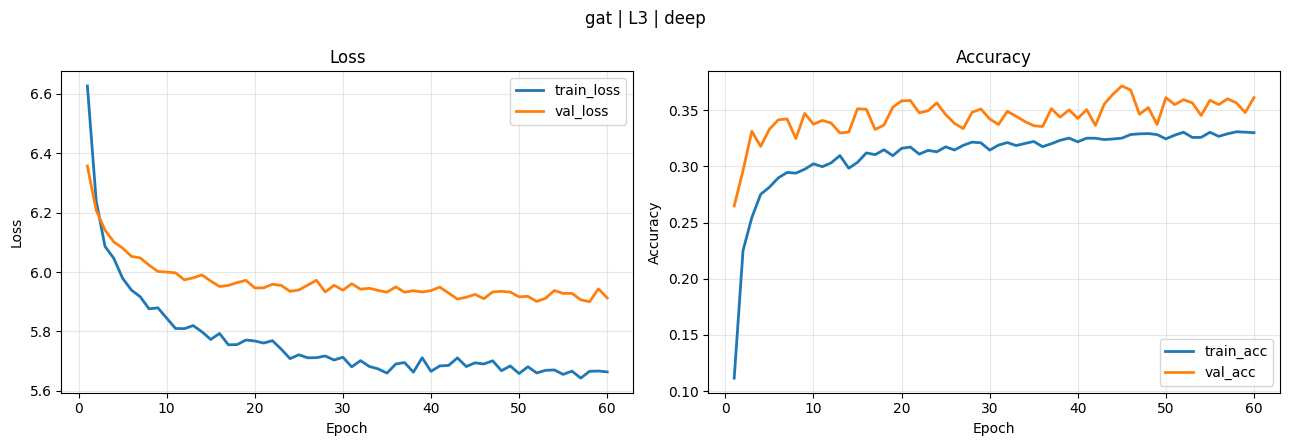

{'loss': 3.008886500321527,
 'acc': 0.35010224948875257,
 'macro_f1': 0.16741086819114595,
 'weighted_f1': 0.34920248101150336,
 'top1_acc': 0.35010224948875257,
 'top3_acc': 0.5269938650306748,
 'top5_acc': 0.6030674846625766,
 'val_acc_best': 0.37142857142857144}

In [3]:
clear_cuda()
cfg_l3 = ExperimentConfig(
    method='gat', level='L3', feature_source='deep',
    epochs=60, batch_size=8, grad_accum_steps=2, lr=5e-4, weight_decay=1e-3,
    hidden_dim=128, heads=8, dropout=0.4,
    hierarchical=False,
)
out_l3 = run_experiment(cfg_l3, ckpt_root=CKPT_ROOT, plot_root=PLOT_ROOT)
out_l3['metrics']